In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
BASE_DIR = "/home/bee-humble/workspace/class_project_ws/src/perception_module"
DATA_DIR = os.path.join(BASE_DIR, "data/audio")

water_dir = os.path.join(DATA_DIR, "water")
empty_dir = os.path.join(DATA_DIR, "empty")

print("Water samples:", len(os.listdir(water_dir)))
print("Empty samples:", len(os.listdir(empty_dir)))

Water samples: 10
Empty samples: 11


In [5]:
def load_audio(file):
    y, sr = librosa.load(file, sr=16000)
    return y, sr

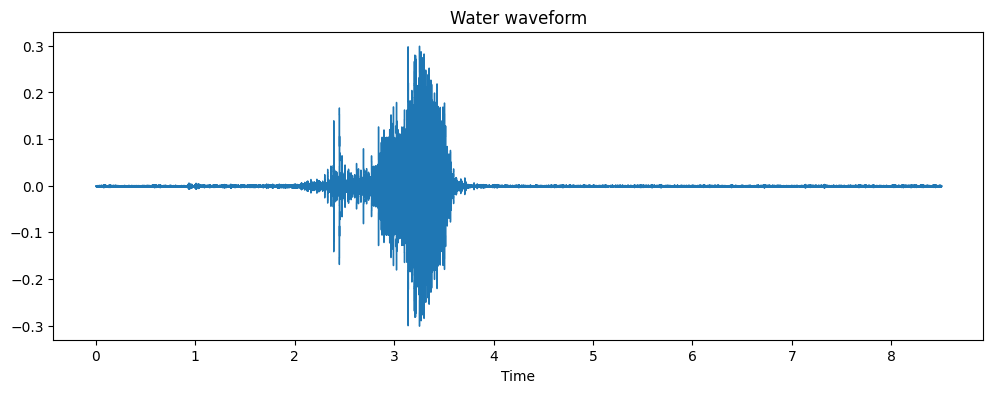

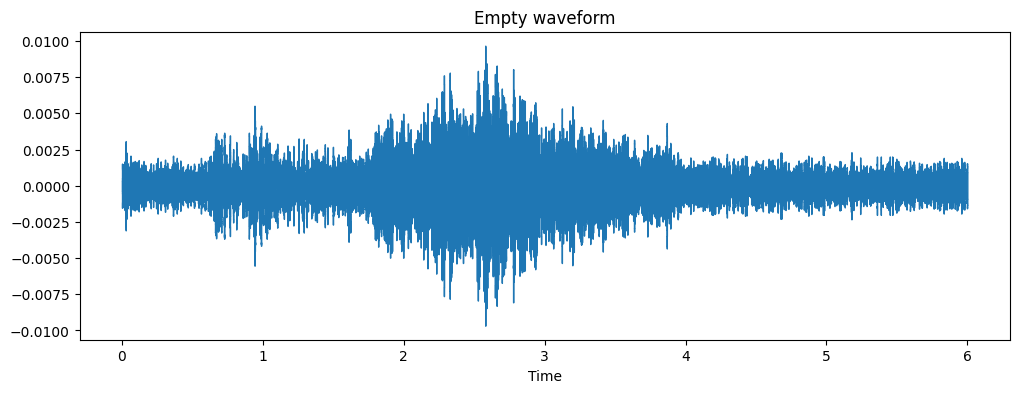

In [6]:
water_file = os.path.join(water_dir, os.listdir(water_dir)[0])
empty_file = os.path.join(empty_dir, os.listdir(empty_dir)[0])

y_w, sr = load_audio(water_file)
y_e, _ = load_audio(empty_file)

plt.figure(figsize=(12,4))
plt.title("Water waveform")
librosa.display.waveshow(y_w, sr=sr)
plt.show()

plt.figure(figsize=(12,4))
plt.title("Empty waveform")
librosa.display.waveshow(y_e, sr=sr)
plt.show()

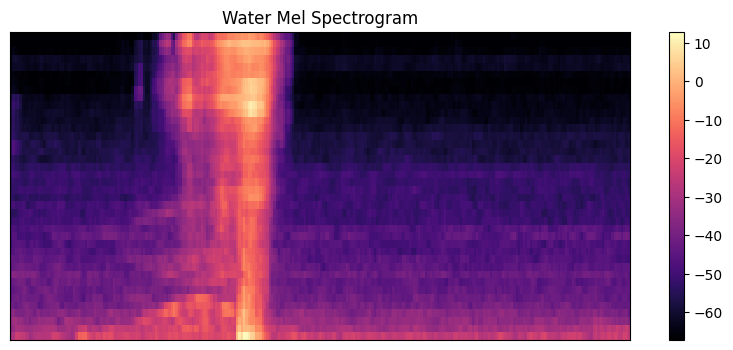

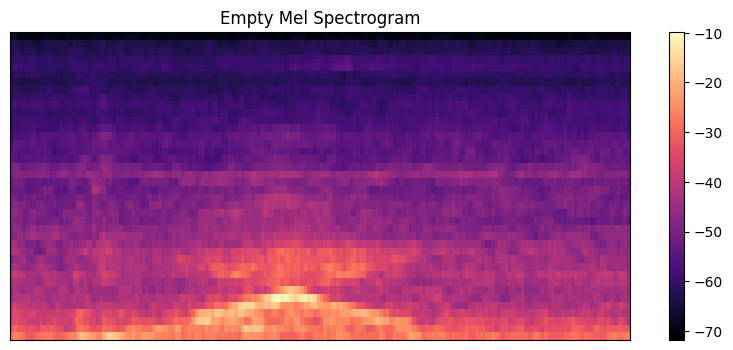

In [7]:
def plot_mel(y, sr, title):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    log_mel = librosa.power_to_db(mel)

    plt.figure(figsize=(10,4))
    librosa.display.specshow(log_mel, sr=sr)
    plt.title(title)
    plt.colorbar()
    plt.show()

plot_mel(y_w, sr, "Water Mel Spectrogram")
plot_mel(y_e, sr, "Empty Mel Spectrogram")

In [32]:
def extract_feature(file_path):
    y, sr = librosa.load(file_path, sr=16000)

    # keep only [1s, 4s]
    start = int(1 * sr)
    end = int(4 * sr)
    y = y[start:end]

    # ensure fixed length (3 sec)
    target_len = 3 * sr
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # normalization (fix volumn issue)
    y = y / (np.max(np.abs(y)) + 1e-6)

    # log-mel
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    log_mel = librosa.power_to_db(mel)

    return np.mean(log_mel, axis=1)

In [33]:
X, y = [], []

for file in os.listdir(water_dir):
    if file.endswith(".wav"):
        X.append(extract_feature(os.path.join(water_dir, file)))
        y.append(1)

for file in os.listdir(empty_dir):
    if file.endswith(".wav"):
        X.append(extract_feature(os.path.join(empty_dir, file)))
        y.append(0)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (21, 40)


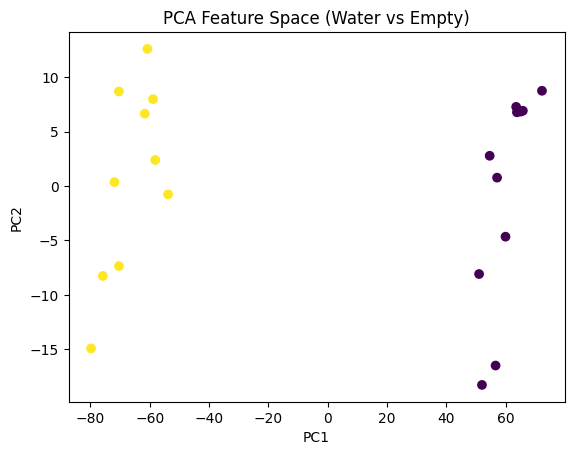

In [34]:
from sklearn.decomposition import PCA

X_2d = PCA(n_components=2).fit_transform(X)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=y)
plt.title("PCA Feature Space (Water vs Empty)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [36]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7

Confusion Matrix:
 [[3 0]
 [0 4]]


In [38]:
probs = model.predict_proba(X_test)

for i in range(len(y_test)):
    print(f"True: {y_test[i]} | Pred: {y_pred[i]} | Prob: {probs[i]}")

True: 1 | Pred: 1 | Prob: [2.81215003e-04 9.99718785e-01]
True: 0 | Pred: 0 | Prob: [9.99816808e-01 1.83191544e-04]
True: 0 | Pred: 0 | Prob: [9.99659084e-01 3.40916153e-04]
True: 1 | Pred: 1 | Prob: [4.69068029e-05 9.99953093e-01]
True: 1 | Pred: 1 | Prob: [2.74561380e-05 9.99972544e-01]
True: 1 | Pred: 1 | Prob: [1.90881665e-04 9.99809118e-01]
True: 0 | Pred: 0 | Prob: [9.99978275e-01 2.17252465e-05]


In [39]:
def predict_file(file_path):
    feat = extract_feature(file_path)
    pred = model.predict([feat])[0]
    return "water" if pred == 1 else "empty"

test_file = water_file
print("Prediction:", predict_file(test_file))

Prediction: water


In [40]:
import numpy as np

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

In [41]:
from sklearn.linear_model import LogisticRegression

model_2d = LogisticRegression()
model_2d.fit(X_2d, y)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

In [42]:
import numpy as np

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

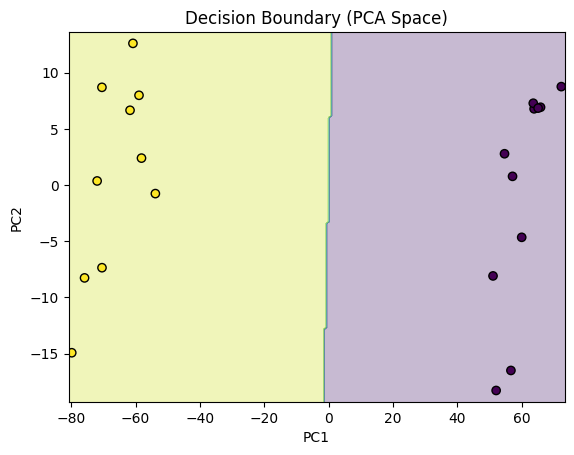

In [43]:
import matplotlib.pyplot as plt

plt.figure()

# decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# data points
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors='k')

plt.title("Decision Boundary (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [44]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
correct = 0

for train_idx, test_idx in loo.split(X):
    model = LogisticRegression()
    model.fit(X[train_idx], y[train_idx])

    pred = model.predict(X[test_idx])[0]
    if pred == y[test_idx][0]:
        correct += 1

print("LOO Accuracy:", correct / len(X))

LOO Accuracy: 1.0


In [45]:

model = LogisticRegression()
model.fit(X, y)

print("✅ Trained on full dataset")

✅ Trained on full dataset


In [46]:
import os
import pickle

MODEL_DIR = "/home/bee-humble/workspace/class_project_ws/src/perception_module/models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "audio_model.pkl")

with open(model_path, "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved to:", model_path)

✅ Model saved to: /home/bee-humble/workspace/class_project_ws/src/perception_module/models/audio_model.pkl


In [47]:
import pickle
import os

MODEL_PATH = "/home/bee-humble/workspace/class_project_ws/src/perception_module/models/audio_model.pkl"

def load_model():
    with open(MODEL_PATH, "rb") as f:
        return pickle.load(f)

model = load_model()


def predict_audio(file_path):
    feat = extract_feature(file_path)
    pred = model.predict([feat])[0]

    return "water" if pred == 1 else "empty"